## Practice Lecture 18 - Training DNN
In this lab we will look at how to train Deep Neural Networks for classification and regression. \
Based on Chapter 11 from Aurelien Geron's book, Hands-on Machine Learning with Scikit-Learn Keras & Tensorflow.\
Original code examples from book in github [here](https://github.com/ageron/handson-ml2)

<table align="left">
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/dtrad/geoml_course/blob/master/Practice18_trainingDNN.ipynb"><img src="https://www.tensorflow.org/images/colab_logo_32px.png" />Run in Google Colab</a>
  </td>
</table>

In [1]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

try:
    # %tensorflow_version only exists in Colab.
    %tensorflow_version 2.x
except Exception:
    pass

# TensorFlow ≥2.0 is required
import tensorflow as tf
from tensorflow import keras
assert tf.__version__ >= "2.0"

# Common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt


## Exercise 1: activation functions
Plot activation functions logit, relu and leaky-relu

In [2]:
z=np.arange(-5,5,0.1)

In [3]:
def logit(z):
    return 1 / (1 + np.exp(-z))

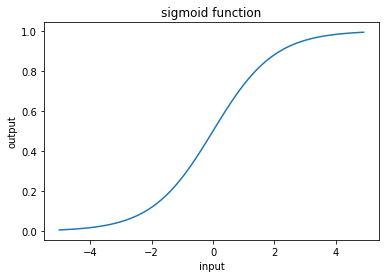

In [4]:
plt.figure()
plt.plot(z,logit(z))
plt.xlabel('input')
plt.ylabel('output')
plt.title('sigmoid function');

In [6]:
def leaky_relu(z, alpha=0.01):
    return np.maximum(alpha*z, z)

when Leaky Relu has coefficient $alpha=0$ it is the same as RELU

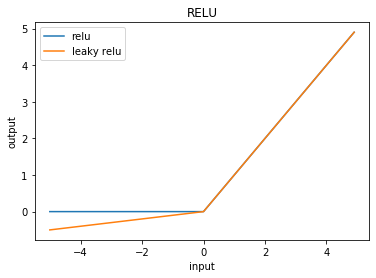

In [8]:
plt.plot(z,leaky_relu(z,0.0),label='relu')
plt.plot(z,leaky_relu(z,0.1),label='leaky relu')
plt.legend()
plt.xlabel('input')
plt.ylabel('output')
plt.title('RELU');

## Exercise 2: training for MNIST with different activation functions and initialization
Train a network for MNIST data using leaky_relu and compare with relu and sigmoid. Also compare two different initializations "he_init" and "zeros".\
For each case plot the loss and validations curves and evaluate on the test data.\
What does it work and what doesn't?

In [9]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]

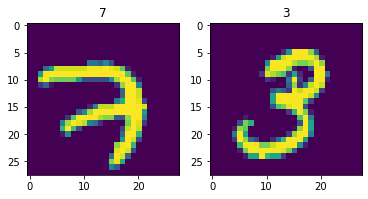

In [10]:
plt.figure()
plt.subplot(121);plt.imshow(X_train[0]);plt.title(y_train[0]);
plt.subplot(122);plt.imshow(X_train[1]);plt.title(y_train[1]);


In [12]:
dir(keras.initializers)

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 '__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 '_sys',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [11]:
[m for m in dir(keras.initializers) if not m.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [13]:
[m for m in dir(keras.activations) if not m.startswith("_")]

['deserialize',
 'elu',
 'exponential',
 'get',
 'hard_sigmoid',
 'linear',
 'relu',
 'selu',
 'serialize',
 'sigmoid',
 'softmax',
 'softplus',
 'softsign',
 'tanh']

In [14]:
[m for m in dir(keras.layers) if "relu" in m.lower()]

['LeakyReLU', 'PReLU', 'ReLU', 'ThresholdedReLU']

In [15]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.Dense(10, activation="softmax")
])

In [16]:
model.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [17]:
model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten (Flatten)            (None, 784)               0         
_________________________________________________________________
dense (Dense)                (None, 300)               235500    
_________________________________________________________________
leaky_re_lu (LeakyReLU)      (None, 300)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_1 (LeakyReLU)    (None, 100)               0         
_________________________________________________________________
dense_2 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
__________________________________________________

In [18]:
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 5s 82us/sample - loss: 1.4688 - accuracy: 0.6154 - val_loss: 0.9004 - val_accuracy: 0.8078
Epoch 2/10
55000/55000 [==============================] - 4s 70us/sample - loss: 0.7220 - accuracy: 0.8296 - val_loss: 0.5786 - val_accuracy: 0.8612
Epoch 3/10
55000/55000 [==============================] - 4s 71us/sample - loss: 0.5350 - accuracy: 0.8613 - val_loss: 0.4675 - val_accuracy: 0.8822
Epoch 4/10
55000/55000 [==============================] - 4s 71us/sample - loss: 0.4573 - accuracy: 0.8772 - val_loss: 0.4122 - val_accuracy: 0.8930
Epoch 5/10
55000/55000 [==============================] - 4s 71us/sample - loss: 0.4140 - accuracy: 0.8862 - val_loss: 0.3774 - val_accuracy: 0.9006
Epoch 6/10
55000/55000 [==============================] - 4s 71us/sample - loss: 0.3858 - accuracy: 0.8930 - val_loss: 0.3542 - val_accuracy: 0.9072
Epoch 7/10
55000/55000 [==============================] -

In [19]:
model.evaluate(X_test,y_test)

10000/10000 [==============================] - 1s 52us/sample - loss: 0.3067 - accuracy: 0.9145


[0.30669969602823255, 0.9145]

In [22]:
history.params

{'batch_size': 32,
 'epochs': 10,
 'steps': 1719,
 'samples': 55000,
 'verbose': 0,
 'do_validation': True,
 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}

In [20]:
history.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

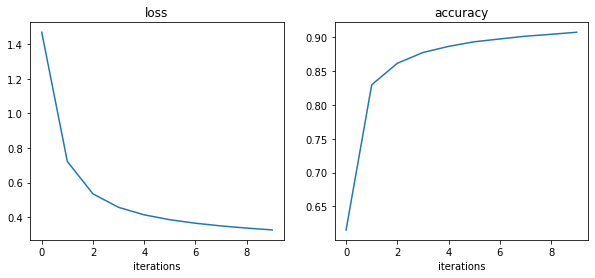

In [23]:
def plot_history(history):
    plt.figure(figsize=(10,4))
    plt.subplot(121);plt.plot(history.history["loss"])
    plt.xlabel('iterations')
    plt.title('loss')
    plt.subplot(122);plt.plot(history.history["accuracy"])
    plt.xlabel('iterations')
    plt.title('accuracy');
    
plot_history(history)

Let us compare with the standard RELU activation

In [24]:
model2 = keras.models.Sequential()
model2.add(keras.layers.Flatten(input_shape=[28,28]))
model2.add(keras.layers.Dense(300,activation="relu"))
model2.add(keras.layers.Dense(100,activation="relu"))
model2.add(keras.layers.Dense(10,activation="softmax"))

In [25]:
model2.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [26]:
model2.summary()

Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_1 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_3 (Dense)              (None, 300)               235500    
_________________________________________________________________
dense_4 (Dense)              (None, 100)               30100     
_________________________________________________________________
dense_5 (Dense)              (None, 10)                1010      
Total params: 266,610
Trainable params: 266,610
Non-trainable params: 0
_________________________________________________________________


In [27]:
history2 = model2.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 78us/sample - loss: 1.6891 - accuracy: 0.5735 - val_loss: 1.1217 - val_accuracy: 0.7652
Epoch 2/10
55000/55000 [==============================] - 4s 69us/sample - loss: 0.8515 - accuracy: 0.8192 - val_loss: 0.6567 - val_accuracy: 0.8508
Epoch 3/10
55000/55000 [==============================] - 4s 71us/sample - loss: 0.5834 - accuracy: 0.8607 - val_loss: 0.5029 - val_accuracy: 0.8744
Epoch 4/10
55000/55000 [==============================] - 4s 70us/sample - loss: 0.4791 - accuracy: 0.8769 - val_loss: 0.4293 - val_accuracy: 0.8858
Epoch 5/10
55000/55000 [==============================] - 4s 70us/sample - loss: 0.4244 - accuracy: 0.8859 - val_loss: 0.3861 - val_accuracy: 0.8968
Epoch 6/10
55000/55000 [==============================] - 4s 71us/sample - loss: 0.3904 - accuracy: 0.8932 - val_loss: 0.3568 - val_accuracy: 0.9030
Epoch 7/10
55000/55000 [==============================] -

In [28]:
model2.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 50us/sample - loss: 0.3010 - accuracy: 0.9151


[0.3010010985434055, 0.9151]

In [29]:
print(history.params)
print(history2.params)

{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}
{'batch_size': 32, 'epochs': 10, 'steps': 1719, 'samples': 55000, 'verbose': 0, 'do_validation': True, 'metrics': ['loss', 'accuracy', 'val_loss', 'val_accuracy']}


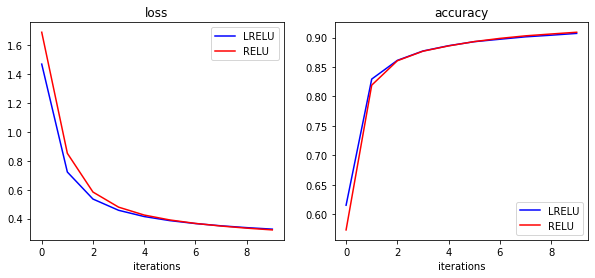

In [30]:
def plot_history(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_history(history,history2,'LRELU','RELU')

We can see different activation functions implemented in Keras using dir(keras.activations)

In [73]:
model3 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="he_normal",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model3.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])

In [74]:
history3 = model3.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))


Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 3s 63us/sample - loss: 2.3011 - accuracy: 0.2408 - val_loss: 2.2366 - val_accuracy: 0.3896
Epoch 2/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.2048 - accuracy: 0.4557 - val_loss: 2.1679 - val_accuracy: 0.5254
Epoch 3/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.1324 - accuracy: 0.5302 - val_loss: 2.0884 - val_accuracy: 0.5588
Epoch 4/10
55000/55000 [==============================] - 3s 56us/sample - loss: 2.0479 - accuracy: 0.5651 - val_loss: 1.9962 - val_accuracy: 0.5696
Epoch 5/10
55000/55000 [==============================] - 3s 56us/sample - loss: 1.9504 - accuracy: 0.5763 - val_loss: 1.8918 - val_accuracy: 0.6046
Epoch 6/10
55000/55000 [==============================] - 3s 56us/sample - loss: 1.8437 - accuracy: 0.5991 - val_loss: 1.7811 - val_accuracy: 0.5952
Epoch 7/10
55000/55000 [==============================] -

In [75]:
model3.evaluate(X_test,y_test)

10000/10000 [==============================] - 0s 37us/sample - loss: 1.4241 - accuracy: 0.6670


[1.424063034248352, 0.667]

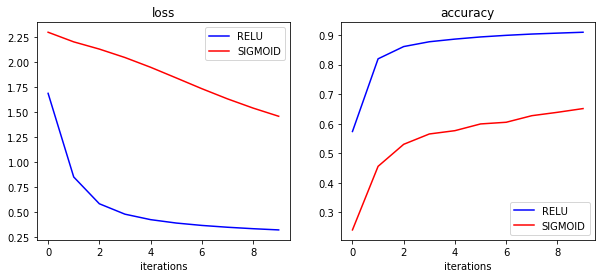

In [76]:
plot_history(history2,history3,'RELU','SIGMOID')

The same for initializers. We can check what is available by dir(keras.initializers)

In [77]:
[m for m in dir(keras.initializers) if not m.startswith("_")]

['Constant',
 'GlorotNormal',
 'GlorotUniform',
 'Identity',
 'Initializer',
 'Ones',
 'Orthogonal',
 'RandomNormal',
 'RandomUniform',
 'TruncatedNormal',
 'VarianceScaling',
 'Zeros',
 'constant',
 'deserialize',
 'get',
 'glorot_normal',
 'glorot_uniform',
 'he_normal',
 'he_uniform',
 'identity',
 'lecun_normal',
 'lecun_uniform',
 'ones',
 'orthogonal',
 'serialize',
 'zeros']

In [41]:
model4 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(100, kernel_initializer="zeros",activation="sigmoid"),
    keras.layers.Dense(10, activation="softmax")
])
model4.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history4 = model4.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model4.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 4s 77us/sample - loss: 2.3178 - accuracy: 0.1067 - val_loss: 2.3012 - val_accuracy: 0.1126
Epoch 2/10
55000/55000 [==============================] - 4s 70us/sample - loss: 2.3015 - accuracy: 0.1123 - val_loss: 2.3011 - val_accuracy: 0.1126
Epoch 3/10
55000/55000 [==============================] - 4s 70us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3014 - val_accuracy: 0.1126
Epoch 4/10
55000/55000 [==============================] - 4s 71us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3011 - val_accuracy: 0.1126
Epoch 5/10
55000/55000 [==============================] - 4s 71us/sample - loss: 2.3014 - accuracy: 0.1123 - val_loss: 2.3008 - val_accuracy: 0.1126
Epoch 6/10
55000/55000 [==============================] - 4s 71us/sample - loss: 2.3012 - accuracy: 0.1123 - val_loss: 2.3012 - val_accuracy: 0.1126
Epoch 7/10
55000/55000 [==============================] -

[2.3006607040405274, 0.1135]

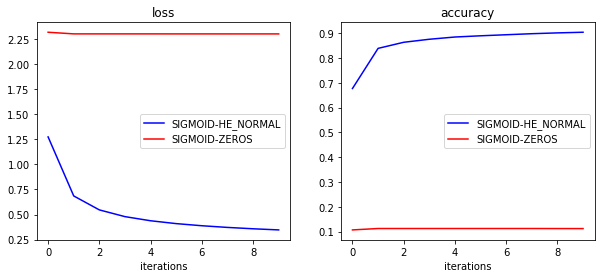

In [42]:
plot_history(history3,history4,'SIGMOID-HE_NORMAL','SIGMOID-ZEROS')

## Exercise 3: 
Use the first model with/without batch normalization. Plot the loss and accuracy curves for training and validation. Do you see any difference?
How many more parameters you need to optimize and why?

In [43]:
model5 = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(300, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(100, kernel_initializer="he_normal"),
    keras.layers.LeakyReLU(),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(10, activation="softmax")
])

In [44]:
model5.summary()

Model: "sequential_5"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_5 (Flatten)          (None, 784)               0         
_________________________________________________________________
batch_normalization (BatchNo (None, 784)               3136      
_________________________________________________________________
dense_15 (Dense)             (None, 300)               235500    
_________________________________________________________________
leaky_re_lu_2 (LeakyReLU)    (None, 300)               0         
_________________________________________________________________
batch_normalization_1 (Batch (None, 300)               1200      
_________________________________________________________________
dense_16 (Dense)             (None, 100)               30100     
_________________________________________________________________
leaky_re_lu_3 (LeakyReLU)    (None, 100)              

In [45]:
model5.compile(loss="sparse_categorical_crossentropy",
              optimizer=keras.optimizers.SGD(lr=1e-3),
              metrics=["accuracy"])
history5 = model5.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
model5.evaluate(X_test,y_test)

Train on 55000 samples, validate on 5000 samples
Epoch 1/10
55000/55000 [==============================] - 7s 127us/sample - loss: 0.9002 - accuracy: 0.7268 - val_loss: 0.5044 - val_accuracy: 0.8506
Epoch 2/10
55000/55000 [==============================] - 6s 112us/sample - loss: 0.4849 - accuracy: 0.8587 - val_loss: 0.3873 - val_accuracy: 0.8876
Epoch 3/10
55000/55000 [==============================] - 6s 112us/sample - loss: 0.4140 - accuracy: 0.8786 - val_loss: 0.3370 - val_accuracy: 0.9034
Epoch 4/10
55000/55000 [==============================] - 6s 112us/sample - loss: 0.3738 - accuracy: 0.8908 - val_loss: 0.3069 - val_accuracy: 0.9130
Epoch 5/10
55000/55000 [==============================] - 6s 112us/sample - loss: 0.3441 - accuracy: 0.8995 - val_loss: 0.2843 - val_accuracy: 0.9184
Epoch 6/10
55000/55000 [==============================] - 6s 112us/sample - loss: 0.3260 - accuracy: 0.9047 - val_loss: 0.2707 - val_accuracy: 0.9220
Epoch 7/10
55000/55000 [===========================

[0.23923520275056362, 0.9318]

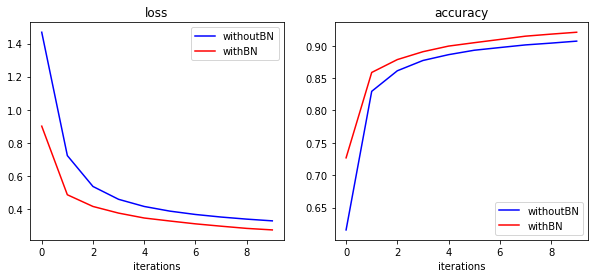

In [46]:
plot_history(history, history5, 'withoutBN','withBN')

## Exercise 4
Load the fashion_mnist model as shown below and train it to do multiclass classification as shown on the book's notebook.\
When training remove classes 8 and 9 to use them as a different dataset.\
Then take only these two classes and do binary classification on them.\
Instead of training the network from scratch, start from the network trained for the full data set. \
Replace the last layer for a sigmoid (softmax, i.e. multiclass, to sigmoid, binary classification). 

We take the full dataset first

In [47]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

Now we split the data into two new data sets, A and B. \
A has 7 classes (all original classes without 8 and 9) and can be classified with multiclass methods.\
B has 2 classes (Bag is false, Ankle Boot is True.\
We will train on the model A and then use it for B.\
That is we will switch from multiclass to binary classification.

In [48]:
print(class_names[8:10])
def split_dataset(X, y):
    y_8_or_9 = (y == 8) | (y == 9) # bag or ankle boots
    y_A = y[~y_8_or_9]    
    y_B = (y[y_8_or_9] == 9).astype(np.float32) # binary classification task, 8 False, 9 True
    return ((X[~y_8_or_9], y_A),
            (X[y_8_or_9], y_B))

(X_train_A, y_train_A), (X_train_B, y_train_B) = split_dataset(X_train, y_train)
(X_valid_A, y_valid_A), (X_valid_B, y_valid_B) = split_dataset(X_valid, y_valid)
(X_test_A, y_test_A), (X_test_B, y_test_B) = split_dataset(X_test, y_test)
X_train_B = X_train_B[:200]
y_train_B = y_train_B[:200]

['Bag', 'Ankle boot']


Let us check the indexes for model A and model B to make sure we did make mistakes.

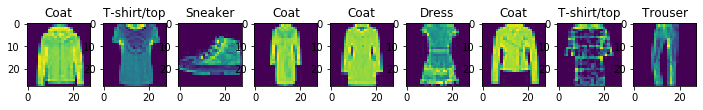

In [49]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_train_A[i]);plt.title(class_names[y_train_A[i]])

In [50]:
class_nameB=['bag','boot']

1.0
1.0
1.0
0.0
0.0
0.0
1.0
1.0
1.0


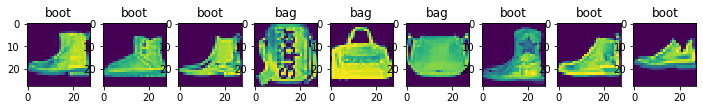

In [51]:
plt.figure(figsize=(12,6))
for i in range(9):
    print(y_train_B[i])
    plt.subplot(191+i)
    plt.imshow(X_train_B[i]);plt.title(class_nameB[np.int8(y_train_B[i])])

Now we start training model A. We build a sequential model as we did before.

In [52]:
tf.random.set_seed(42)
np.random.seed(42)

In [53]:
model_A = keras.models.Sequential()
model_A.add(keras.layers.Flatten(input_shape=[28, 28]))
for n_hidden in (300, 100, 50, 50, 50):
    model_A.add(keras.layers.Dense(n_hidden, activation="selu"))
model_A.add(keras.layers.Dense(8, activation="softmax"))

But we train it using the dataset A. We will train from scratch.

In [54]:
model_A.compile(loss="sparse_categorical_crossentropy",
                optimizer=keras.optimizers.SGD(lr=1e-3),
                metrics=["accuracy"])
model_A.fit(X_train_A,y_train_A,validation_data=(X_valid_A,y_valid_A),epochs=10)

Train on 43996 samples, validate on 4004 samples
Epoch 1/10
43996/43996 [==============================] - 4s 89us/sample - loss: 0.7983 - accuracy: 0.7193 - val_loss: 0.5731 - val_accuracy: 0.7952
Epoch 2/10
43996/43996 [==============================] - 4s 81us/sample - loss: 0.5486 - accuracy: 0.8021 - val_loss: 0.5064 - val_accuracy: 0.8257
Epoch 3/10
43996/43996 [==============================] - 3s 79us/sample - loss: 0.5008 - accuracy: 0.8166 - val_loss: 0.4785 - val_accuracy: 0.8259
Epoch 4/10
43996/43996 [==============================] - 3s 80us/sample - loss: 0.4740 - accuracy: 0.8270 - val_loss: 0.4571 - val_accuracy: 0.8352
Epoch 5/10
43996/43996 [==============================] - 4s 80us/sample - loss: 0.4552 - accuracy: 0.8323 - val_loss: 0.4516 - val_accuracy: 0.8362
Epoch 6/10
43996/43996 [==============================] - 4s 80us/sample - loss: 0.4419 - accuracy: 0.8382 - val_loss: 0.4373 - val_accuracy: 0.8412
Epoch 7/10
43996/43996 [==============================] -

In [55]:
model_A.summary()

Model: "sequential_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_6 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_18 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_19 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_20 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_21 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_22 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_23 (Dense)             (None, 8)                

The main part of this exercise is to train for dataset B but starting from the model trained in dataset A.\
Notice that model A has never seeing a bag or ankle boot. Let use save the model first.

In [56]:
model_A.save("my_model_A.h5")

Now we will create a new model B by using layers from modelA except for the last one (the softmax with the softmax activation) since these layer was designed for multiclasses.\
We will replace this last layer with a simpler sigmoid (as usual for binary classification).

In [57]:
model_A = keras.models.load_model("my_model_A.h5")
model_B_on_A = keras.models.Sequential(model_A.layers[:-1])
model_B_on_A.add(keras.layers.Dense(1, activation="sigmoid"))

In [58]:
for i in np.arange(len(model_A.layers)): 
    print(model_A.layers[i].name,'\t',model_B_on_A.layers[i].name)

flatten_6 	 flatten_6
dense_18 	 dense_18
dense_19 	 dense_19
dense_20 	 dense_20
dense_21 	 dense_21
dense_22 	 dense_22
dense_23 	 dense_24


We need to fix the weights for all layers except the last one we want to change.

In [59]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = False

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])

In [60]:
model_B_on_A.summary()

Model: "sequential_7"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
flatten_6 (Flatten)          (None, 784)               0         
_________________________________________________________________
dense_18 (Dense)             (None, 300)               235500    
_________________________________________________________________
dense_19 (Dense)             (None, 100)               30100     
_________________________________________________________________
dense_20 (Dense)             (None, 50)                5050      
_________________________________________________________________
dense_21 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_22 (Dense)             (None, 50)                2550      
_________________________________________________________________
dense_24 (Dense)             (None, 1)                

Now let us evaluate the models in the datasets A and B.\
Since model_A was already training for dataset A, it produces a good result for testA

In [61]:
model_A.evaluate(X_test_A, y_test_A)

8000/8000 [==============================] - 1s 64us/sample - loss: 0.4574 - accuracy: 0.8316


[0.45737804663181303, 0.831625]

The last layer of model_B_on_A has not been trained yet for dataset B. The rest of the layers are good. Let us try it to see if the last layer is important.

In [62]:
model_B_on_A.evaluate(X_test_B, y_test_B)

2000/2000 [==============================] - 0s 116us/sample - loss: 1.4743 - accuracy: 0.3835


[1.4742729711532592, 0.3835]

Let us now train the last layer.

In [63]:
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=4,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/4
200/200 [==============================] - 0s 2ms/sample - loss: 1.4376 - accuracy: 0.3850 - val_loss: 1.4334 - val_accuracy: 0.3855
Epoch 2/4
200/200 [==============================] - 0s 418us/sample - loss: 1.3649 - accuracy: 0.3850 - val_loss: 1.3592 - val_accuracy: 0.3825
Epoch 3/4
200/200 [==============================] - 0s 404us/sample - loss: 1.2946 - accuracy: 0.3900 - val_loss: 1.2843 - val_accuracy: 0.3775
Epoch 4/4
2000/2000 [==============================] - 0s 53us/sample - loss: 1.1890 - accuracy: 0.3825


[1.1890180921554565, 0.3825]

In [64]:
y_prob_B = model_B_on_A.predict(X_test_B)

/home/dtrad/anaconda3/envs/tfgpu2/lib/python3.7/site-packages/matplotlib/text.py:1150: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


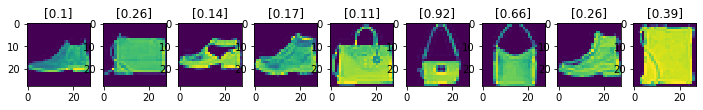

In [65]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title(np.round(y_prob_B[i],2))

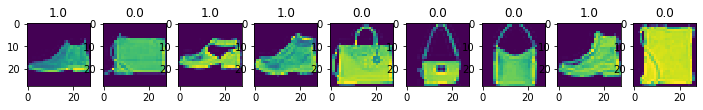

In [66]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title((y_test_B[i]))

It looks like we need to train a bit more than just the last layer. Let us make them all layers trainable.

In [67]:
for layer in model_B_on_A.layers[:-1]:
    layer.trainable = True

model_B_on_A.compile(loss="binary_crossentropy",
                     optimizer=keras.optimizers.SGD(lr=1e-3),
                     metrics=["accuracy"])
history = model_B_on_A.fit(X_train_B, y_train_B, epochs=16,
                           validation_data=(X_valid_B, y_valid_B))
model_B_on_A.evaluate(X_test_B, y_test_B)

Train on 200 samples, validate on 996 samples
Epoch 1/16
200/200 [==============================] - 1s 3ms/sample - loss: 1.0375 - accuracy: 0.3850 - val_loss: 0.8773 - val_accuracy: 0.4177
Epoch 2/16
200/200 [==============================] - 0s 466us/sample - loss: 0.7594 - accuracy: 0.4900 - val_loss: 0.6678 - val_accuracy: 0.5904
Epoch 3/16
200/200 [==============================] - 0s 447us/sample - loss: 0.5766 - accuracy: 0.7100 - val_loss: 0.5274 - val_accuracy: 0.8042
Epoch 4/16
200/200 [==============================] - 0s 407us/sample - loss: 0.4556 - accuracy: 0.8500 - val_loss: 0.4385 - val_accuracy: 0.8735
Epoch 5/16
200/200 [==============================] - 0s 421us/sample - loss: 0.3757 - accuracy: 0.9250 - val_loss: 0.3684 - val_accuracy: 0.9267
Epoch 6/16
200/200 [==============================] - 0s 413us/sample - loss: 0.3162 - accuracy: 0.9700 - val_loss: 0.3251 - val_accuracy: 0.9438
Epoch 7/16
200/200 [==============================] - 0s 401us/sample - loss: 0.

[0.13482235777378082, 0.9785]

It did a good job now, but did the original training help at all? 

In [68]:
y_prob_B = model_B_on_A.predict(X_test_B)

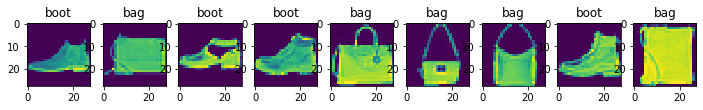

In [69]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);plt.title(class_nameB[np.int8(y_test_B[i])])

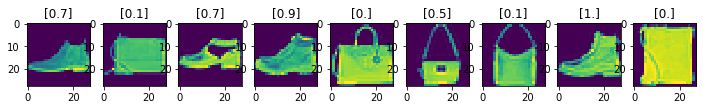

In [70]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    #plt.title(class_nameB[np.int8(y_pred_B[i])])
    plt.title(np.round(y_prob_B[i],1))

In [71]:
y_pred_B = model_B_on_A.predict_classes(X_test_B)
y_pred_B = y_pred_B.flatten()
print(y_pred_B)

[1 0 1 ... 1 1 0]


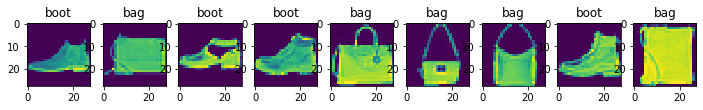

In [72]:
plt.figure(figsize=(12,6))
for i in range(9):    
    plt.subplot(191+i)
    plt.imshow(X_test_B[i]);
    plt.title(class_nameB[y_pred_B[i]])
    

## Exercise 5
Try the classification of the fashion mnist data set using the following optimizers.

In [ ]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()
X_train_full = X_train_full / 255.0
X_test = X_test / 255.0
X_valid, X_train = X_train_full[:5000], X_train_full[5000:]
y_valid, y_train = y_train_full[:5000], y_train_full[5000:]
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
pixel_means = X_train.mean(axis=0, keepdims=True)
pixel_stds = X_train.std(axis=0, keepdims=True)
X_train_scaled = (X_train - pixel_means) / pixel_stds
X_valid_scaled = (X_valid - pixel_means) / pixel_stds
X_test_scaled = (X_test - pixel_means) / pixel_stds

In [ ]:
optimizer1 = keras.optimizers.SGD(lr=0.001, momentum=0.9)

In [ ]:
optimizer2 = keras.optimizers.SGD(lr=0.001, momentum=0.9, nesterov=True)

In [ ]:
optimizer3 = keras.optimizers.RMSprop(lr=0.001, rho=0.9)

In [ ]:
optimizer4 = keras.optimizers.Adam(lr=0.001, beta_1=0.9, beta_2=0.999)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer1, metrics=["accuracy"])

In [ ]:
n_epochs = 10
history1 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [ ]:
history4 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

In [ ]:
def plot_history(history, history2, case1, case2):
    niter=history.params['epochs']
    niter2=history.params['epochs']
    iter=np.arange(niter)
    iter2=np.arange(niter2)
    plt.figure(figsize=(10,4))
    plt.subplot(121);
    plt.plot(iter,history.history["loss"],'b-',label=case1);plt.plot(iter2,history2.history['loss'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('loss')
    plt.legend()
    plt.subplot(122);
    plt.plot(iter,history.history["accuracy"],'b-',label=case1);plt.plot(iter2,history2.history['accuracy'],'r-',label=case2)
    plt.xlabel('iterations')
    plt.title('accuracy');
    plt.legend()
plot_history(history1,history4,'SGD','ADAM')

## Exercise 7: Learning Rate
Use the exponential rate decay defined below and compare with the previous result.

In [ ]:
def exponential_decay(lr0, s):
    def exponential_decay_fn(epoch):
        return lr0 * 0.1**(epoch / s)
    return exponential_decay_fn

exponential_decay_fn = exponential_decay(lr0=0.001, s=20)

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [ ]:
lr_scheduler = keras.callbacks.LearningRateScheduler(exponential_decay_fn)
history4b = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid),
                    callbacks=[lr_scheduler])

In [ ]:
plot_history(history4,history4b,'ADAM','ADAM_EXPLR')

## Exercise 8: Regularization
Modify the previous network using l2 and l1 regularizations and compare with the previous result. Also compare with Dropout.

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.Dense(10, activation="softmax",kernel_regularizer=keras.regularizers.l2(0.001))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [ ]:
history4c = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

In [ ]:
plot_history(history4,history4c,'ADAM','ADAM_L2')

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l1(0.0001)),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal",kernel_regularizer=keras.regularizers.l1(0.0001)),
    keras.layers.Dense(10, activation="softmax",kernel_regularizer=keras.regularizers.l1(0.0001))
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [ ]:
history4d = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

In [ ]:
plot_history(history4c,history4d,'ADAM_L2','ADAM_L1')

### comparing with Dropout

In [ ]:
model = keras.models.Sequential([
    keras.layers.Flatten(input_shape=[28, 28]),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(300, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(100, activation="selu", kernel_initializer="lecun_normal"),
    keras.layers.Dropout(rate=0.2),
    keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer4, metrics=["accuracy"])

In [ ]:
history5 = model.fit(X_train_scaled, y_train, epochs=n_epochs,
                    validation_data=(X_valid_scaled, y_valid))

In [ ]:
plot_history(history4,history5,'ADAM','ADAM_DROPOUT')